##### Instructions

Complete every code location marked **`TODO`**. Run the notebook from top to bottom after completing each section.

By the end of this exercise, you should be able to:

1. implement centroid initialization, assignment, and update steps in K-means;
2. calculate distortion and the silhouette score;
3. compare a from-scratch implementation with scikit-learn;
4. implement the E-step and M-step of a Gaussian Mixture Model (GMM);
5. monitor log-likelihood and use it as a convergence criterion.

**Rules:** Do not call `sklearn.cluster.KMeans` inside the from-scratch K-means class, and do not call `sklearn.mixture.GaussianMixture` inside the from-scratch GMM class. Small numerical constants such as `1e-9` may be added when needed for stability.



## a) Clustering using K-means

### Program 1 - Implementing K-means Clustering from scratch and using scikit learn

#### AIM

To implement K-means clustering from scratch, evaluate the resulting clusters, and compare the implementation with scikit-learn.

#### K-means algorithm

1. Select $k$ observations as the initial centroids.
2. Assign every observation to its nearest centroid.
3. Replace each centroid by the mean of the observations assigned to it.
4. Repeat steps 2–3 until the centroids stop changing (or a maximum number of iterations is reached).

#### Distortion

In this exercise, distortion is the mean Euclidean distance between every observation and its assigned centroid:

$$D = \frac{1}{N}\sum_{i=1}^{N}\lVert\mathbf{x}_i-\boldsymbol{\mu}_{z_i}\rVert_2.$$

#### Silhouette score

For observation $i$, let $a(i)$ be its mean distance to the other points in its own cluster and let $b(i)$ be the smallest mean distance from it to any other cluster. Then

$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}, \qquad S=\frac{1}{N}\sum_i s(i).$$

A score near $1$ indicates well-separated clusters, while a score near $-1$ indicates that many observations may be assigned to the wrong cluster.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.set_printoptions(precision=4, suppress=True)

In [4]:
class KMeans:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X_train, random_state=0):
        n_samples = X_train.shape[0]
        random_gen = np.random.default_rng(random_state)

        # TODO 1: Pick 'n_clusters' unique rows to serve as the starting centroids.
        # Hint: utilize random_gen.choice(..., replace=False)
        start_idx = random_gen.choice(n_samples, size=self.n_clusters, replace=False)
        self.centroids = X_train[start_idx]

        for step in range(self.max_iter):
            prev_centroids = self.centroids.copy()

            # TODO 2: Map all training data points to the closest current centroid.
            dists = cdist(X_train, self.centroids, metric="euclidean")
            self.labels = np.argmin(dists, axis=1)

            # TODO 3: Recalculate centroids by averaging the assigned data points.
            # If a cluster is empty, retain its previous position.
            for k_idx in range(self.n_clusters):
                assigned_pts = X_train[self.labels == k_idx]

                if len(assigned_pts) > 0:
                    self.centroids[k_idx] = np.mean(assigned_pts, axis=0)

            # TODO 4: Terminate the loop if the centroids shift by less than or equal to `self.tol`.
            # Hint: check np.linalg.norm(self.centroids - prev_centroids)
            if np.linalg.norm(self.centroids - prev_centroids) <= self.tol:
                break

        self.n_iter_ = step + 1
        return self

    def predict(self, input_points):
        # TODO 5: Compute distances from the input points to the fitted centroids,
        # then return the index of the closest centroid.
        dists = cdist(input_points, self.centroids, metric="euclidean")
        return np.argmin(dists, axis=1)

#### Part 2 — Defining evaluation metrics

Complete both functions without calling their scikit-learn equivalents. Test the edge cases: a single cluster, a singleton cluster, and more than two clusters.

In [7]:
def distortion(X, labels, centroids):
    # TODO 6: Extract the specific centroid coordinates for each data point
    # and compute the average Euclidean distance across the dataset.
    mapped_centers = centroids[labels]
    euclid_dists = np.linalg.norm(X - mapped_centers, axis=1)
    return np.mean(euclid_dists)


def silhouette_score(X, labels):
    # TODO 7: Calculate the overall mean silhouette score based on the formula.
    # Recommended approach:
    #   a. Construct a pairwise distance matrix using cdist(X, X).
    #   b. For a given point i, compute a(i) (average distance to points in the same cluster).
    #   c. Compute the average distance to points in all other clusters to find the minimum, b(i).
    #   d. Evaluate s(i). Assign a score of 0 if the cluster only contains that single point.
    pairwise_dists = cdist(X, X)
    num_pts = len(labels)
    sil_scores = np.zeros(num_pts)

    clusters = np.unique(labels)

    for i in range(num_pts):
        same_cluster_mask = labels == labels[i]
        same_cluster_mask[i] = False

        if np.sum(same_cluster_mask) == 0:
            sil_scores[i] = 0
            continue

        a_i = np.mean(pairwise_dists[i][same_cluster_mask])

        avg_dists_to_others = []

        for c in clusters:

            if c == labels[i]:
                continue

            diff_cluster_mask = labels == c

            mean_dist = np.mean(
                pairwise_dists[i][diff_cluster_mask]
            )

            avg_dists_to_others.append(mean_dist)

        b_i = np.min(avg_dists_to_others)

        if max(a_i, b_i) == 0:
            sil_scores[i] = 0
        else:
            sil_scores[i] = (b_i - a_i) / max(a_i, b_i)

    return np.mean(sil_scores)

#### Part 3 — Loading the Iris dataset

We use the copy bundled with scikit-learn so that this notebook does not depend on a separate CSV file. The species column is retained only for the later visual comparison; it is not supplied to either clustering algorithm.

In [8]:
from sklearn.datasets import load_iris

iris_data = load_iris(as_frame=True)
df_iris = iris_data.frame.rename(columns={
    "sepal length (cm)": "s_len",
    "sepal width (cm)": "s_wid",
    "petal length (cm)": "p_len",
    "petal width (cm)": "p_wid",
    "target": "species_id",
})

df_iris["species"] = df_iris["species_id"].map(dict(enumerate(iris_data.target_names)))
df_iris = df_iris.drop(columns="species_id")
col_headers = ["s_len", "s_wid", "p_len", "p_wid", "species"]

display(df_iris.head())
print(
    f"Loaded dataset with {df_iris.shape[0]} rows and "
    f"{df_iris.shape[1] - 1} numeric attributes.",
    df_iris["species"].value_counts(),
    sep="\n",
)

,s_len,s_wid,p_len,p_wid,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Loaded dataset with 150 rows and 4 numeric attributes.
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


#### Part 4 - Implementing K-means Clustering

In [9]:
features_matrix = df_iris.drop(columns="species").to_numpy()

# TODO 8: Initialize k matching the number of Iris species, train the KMeans model,
# and prepare the `combined_df` DataFrame for the upcoming visualization.
num_clusters = 3
model_kmeans = KMeans(n_clusters=num_clusters)
model_kmeans.fit(features_matrix)

# Validate the outputs against these assertion checks.
assert model_kmeans is not None, "TODO 8: Initialize and fit the custom KMeans instance."
assert model_kmeans.centroids.shape == (num_clusters, features_matrix.shape[1])
assert model_kmeans.labels.shape == (features_matrix.shape[0],)

combined_df = df_iris.copy(deep=True)
df_centroids = pd.DataFrame(model_kmeans.centroids, columns=col_headers[:-1])
df_centroids["cluster"] = "centroid"
combined_df["cluster"] = model_kmeans.labels.astype(str)
combined_df = pd.concat([combined_df, df_centroids], ignore_index=True)

#### Part 5 - Comparing the Clustering results with original classes

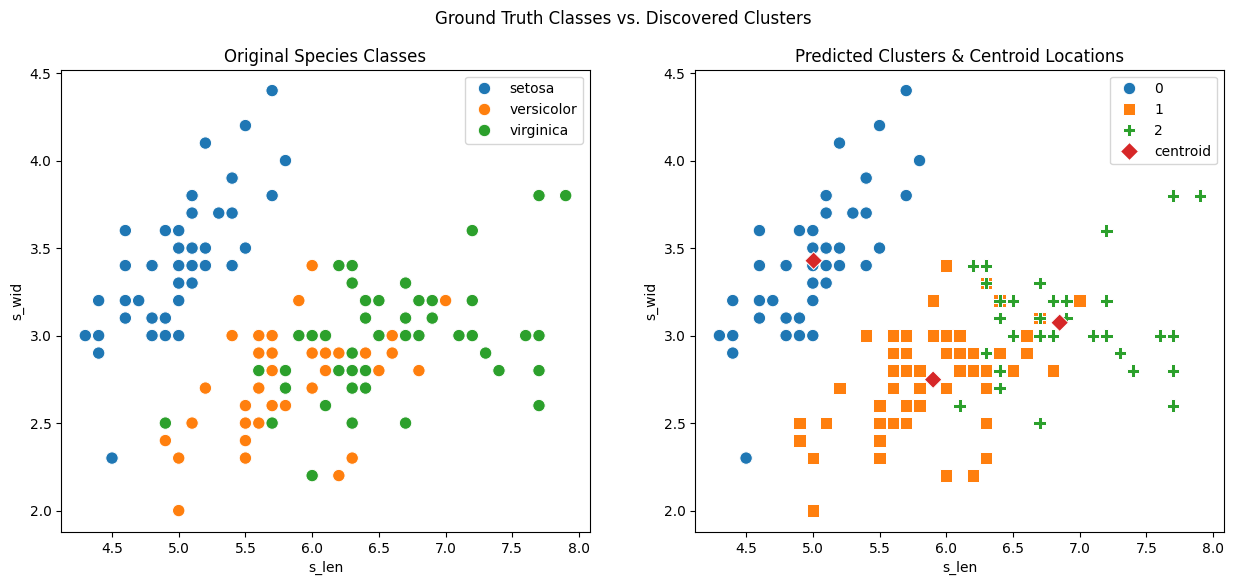

In [11]:
plt.figure(figsize=(15, 6))
plt.suptitle("Ground Truth Classes vs. Discovered Clusters")
plt.subplot(121)
plt.title("Original Species Classes")
sns.scatterplot(data=combined_df, x="s_len", y="s_wid", hue="species", s=80)
plt.legend(loc="upper right")

plt.subplot(122)
plt.title("Predicted Clusters & Centroid Locations")
sns.scatterplot(
    data=combined_df, x="s_len", y="s_wid",
    hue="cluster", style="cluster",
    markers="osPD", s=80
)
plt.legend(loc="upper right")

plt.show()

#### Part 6 — Hyperparameter tuning with multiple values of $k$

Fit the model for $k=2,3,4,5$. Record both metrics and determine whether they favour the same value of $k$.

In [12]:
sil_metrics = []
distortion_scores = []
cluster_range = np.arange(2, 6)

# TODO 9: For every value of k, train the KMeans instance, evaluate the metrics,
# display the outputs, and store the scores in the tracking lists.
for k in cluster_range:
    kmeans_inst = KMeans(n_clusters=k)
    kmeans_inst.fit(features_matrix)
    curr_sil = silhouette_score(features_matrix, kmeans_inst.labels)
    curr_dist = distortion(features_matrix, kmeans_inst.labels, kmeans_inst.centroids)
    print(f"k={k}: silhouette={curr_sil}, distortion={curr_dist}")
    sil_metrics.append(curr_sil)
    distortion_scores.append(curr_dist)

assert len(sil_metrics) == len(cluster_range) and len(distortion_scores) == len(cluster_range), \
    "TODO 9: store one value of each metric for every k"

k=2: silhouette=0.6810461692117464, distortion=0.855577769526653
k=3: silhouette=0.5528190123564101, distortion=0.6480304904934434
k=4: silhouette=0.4940269229276037, distortion=0.5631234184151294
k=5: silhouette=0.36780441787016505, distortion=0.5200412975115446


#### Part 7 - Using Elbow method to Find the optimal value of k


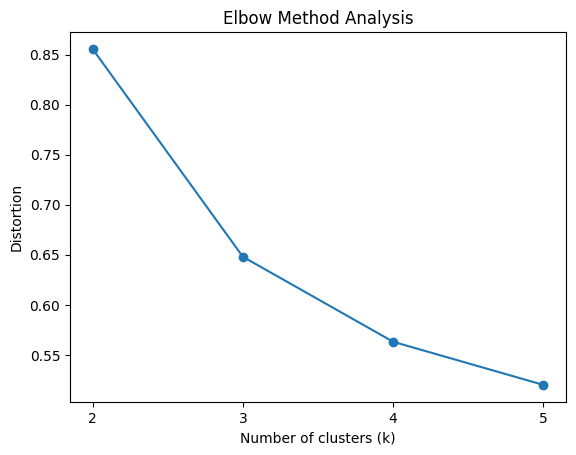

In [13]:
# TODO 10: Plot distortion against k and label both axes.
# Mark each tested value of k on the x-axis.
plt.plot(cluster_range, distortion_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion")
plt.xticks(cluster_range)
plt.title("Elbow Method Analysis")
plt.show()

#### Part 8 -  Implementing K-means clustering with scikit learn

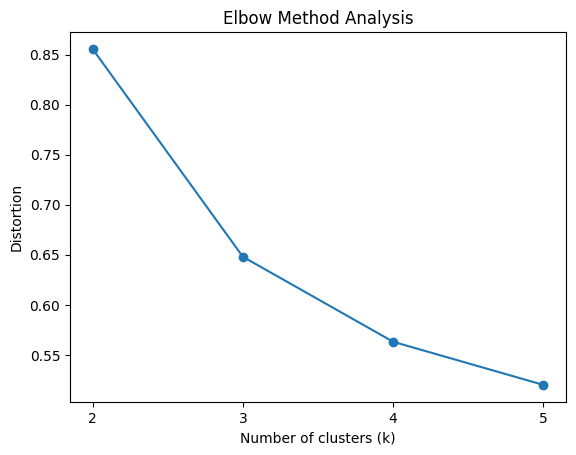

In [14]:
# TODO 10: Plot distortion against k and label both axes.
# Mark each tested value of k on the x-axis.
plt.plot(cluster_range, distortion_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion")
plt.xticks(cluster_range)
plt.title("Elbow Method Analysis")
plt.show()

In [15]:
from sklearn.cluster import KMeans as sklKMeans
from sklearn.metrics import silhouette_score as sk_silhouette_score

In [17]:
# TODO 11: Fit scikit-learn's KMeans for k=3.
# For a reproducible comparison, set init="random", n_init=10, and random_state=0.
# Then calculate its silhouette score and distortion.
cluster_cnt = 3
sklearn_model = sklKMeans(n_clusters=cluster_cnt, init="random", n_init=10, random_state=0)
sklearn_model.fit(features_matrix)
sk_sil = sk_silhouette_score(features_matrix, sklearn_model.labels_)
sk_dist = distortion(features_matrix, sklearn_model.labels_, sklearn_model.cluster_centers_)

# TODO 12: Print both metrics to five decimal places and compare them with
# your from-scratch implementation.
scratch_model = KMeans(n_clusters=3)
scratch_model.fit(features_matrix, random_state=0)
print(f"sklearn silhouette={sk_sil:.5f}, sklearn distortion={sk_dist:.5f}")
print(f"Silhouette Score: {silhouette_score(features_matrix, scratch_model.labels):.5f}")
print(f"Distortion: {distortion(features_matrix, scratch_model.labels, scratch_model.centroids):.5f}")

sklearn silhouette=0.55282, sklearn distortion=0.64803
Silhouette Score: 0.55282
Distortion: 0.64803


## b) Clustering using Gaussian Mixture Model(GMM)

### Program 1 — Implementing a GMM from scratch using the Expectation–Maximization algorithm

#### AIM

To implement a Gaussian Mixture Model (GMM) from scratch using the Expectation–Maximization (EM) algorithm and compare two methods for initializing the component means.

#### Formula:

##### Log-likelihood

For $K$ Gaussian components, the observed-data log-likelihood is

$$
\ell(\theta)=\sum_{i=1}^{N}\log\left[\sum_{k=1}^{K}\pi_k\,
\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)\right].
$$

##### Auxiliary function

$$
Q(\theta,\theta^{(t-1)})=
\sum_i\sum_k r_{ik}\log\pi_k+
\sum_i\sum_k r_{ik}\log p(\mathbf{x}_i\mid\theta_k),
$$

where $r_{ik}=p(z_i=k\mid\mathbf{x}_i,\theta^{(t-1)})$ is the responsibility that component $k$ takes for observation $i$.

##### Responsibility (E-step)

$$
r_{ik}=\frac{\pi_k\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)}
{\sum_{j=1}^{K}\pi_j\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j)}.
$$

For every observation $i$, the responsibilities must satisfy $\sum_k r_{ik}=1$.

##### Parameter updates (M-step)

Let $N_k=\sum_i r_{ik}$. Then

$$
\pi_k=\frac{N_k}{N},\qquad
\boldsymbol{\mu}_k=\frac{\sum_i r_{ik}\mathbf{x}_i}{N_k},\qquad
\boldsymbol{\Sigma}_k=
\frac{\sum_i r_{ik}(\mathbf{x}_i-\boldsymbol{\mu}_k)(\mathbf{x}_i-\boldsymbol{\mu}_k)^T}{N_k}.
$$

#### EM algorithm

1. Initialize the component weights, means, and covariance matrices.
2. **E-step:** calculate the posterior responsibility of every component for every observation.
3. **M-step:** update the weights, means, and covariance matrices using those responsibilities.
4. Evaluate the log-likelihood and repeat steps 2–3 until its improvement is no greater than the tolerance.

#### Part 1 - Defining the class for GMM

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans as SklKMeans

In [19]:
class GMM:
    def __init__(
        self, n_components: int, n_iters: int, tol: float,
        random_state: int = 0, init_params: str = "random",
        reg_covar: float = 1e-6,
    ):
        self.n_components = n_components
        self.n_iters = n_iters
        self.tol = tol
        self.init_params = init_params
        self.random_state = random_state
        self.reg_covar = reg_covar

    def fit(self, X, plot=False, plot_params=None):
        if plot_params is None:
            plot_params = {}

        num_rows, num_cols = X.shape
        self.X = X
        k_clusters = self.n_components

        self.resp = np.zeros((num_rows, k_clusters))
        self.weights = np.full(k_clusters, 1 / k_clusters)

        # TODO 13: Initialize `self.means`.
        # - If init_params == "kmeans", fit SklKMeans and use its centers.
        # - If init_params == "random", select k distinct observations.
        # - Otherwise, raise ValueError for an unsupported method.
        if self.init_params == "kmeans":
            kmeans_estimator = SklKMeans(n_clusters=k_clusters, random_state=self.random_state)
            kmeans_estimator.fit(X)
            self.means = kmeans_estimator.cluster_centers_
        elif self.init_params == "random":
            rng_gen = np.random.default_rng(self.random_state)
            rand_indices = rng_gen.choice(num_rows, size=k_clusters, replace=False)
            self.means = X[rand_indices]
        else:
          raise ValueError("Unsupported initialization method")


        # TODO 14: Initialize every covariance matrix using the covariance of X.
        # Add reg_covar * identity for numerical stability.
        base_covariance = np.cov(X, rowvar=False)
        base_covariance += self.reg_covar * np.eye(num_cols)
        self.covs = np.array([base_covariance.copy() for _ in range(k_clusters)])

        self.converged = False
        self.log_likelihood_trace = []

        if plot:
            fig, ax = plt.subplots(1, 4, figsize=(20, 5))
            fig.suptitle("Gaussian Mixture Model via EM Optimization")
            self.draw(ax[0], "Starting distribution centers", **plot_params)

        for step_idx in range(self.n_iters):
            # TODO 15: Perform one E-step and one M-step.
            self._do_estep(X)
            self._do_mstep(X)

            # TODO 16: Append the current log-likelihood to its trace.
            self.log_likelihood_trace.append(self.log_likelihood)
            self.log_likelihood

            if step_idx == 0 and plot:
                self.draw(ax[1], "Components after 1 epoch", **plot_params)

            if step_idx > 0:
                prev_ll, curr_ll = self.log_likelihood_trace[-2:]
                # TODO 17: Stop if the non-negative log-likelihood improvement
                # is no greater than `self.tol`.
                if curr_ll - prev_ll <= self.tol:
                    self.converged = True
                    break
                if False:
                    self.converged = True
                    break

        self.n_iter_ = step_idx + 1

        if plot:
            self.draw(ax[2], f"Components after convergence ({self.n_iter_} loops)", **plot_params)
            ax[3].plot(self.log_likelihood_trace, "-o")
            ax[3].set_title("Log-Likelihood Progress")
            ax[3].set_xlabel("Epoch")
            plt.show()

        return self

    def _do_estep(self, X):
        # TODO 18: Calculate the unnormalized responsibilities
        # weights[k] * N(X | mean[k], cov[k]) for every component.
        for idx in range(self.n_components):
            self.resp[:, idx] = (self.weights[idx] * multivariate_normal(self.means[idx], self.covs[idx]).pdf(X))

        # TODO 19: Normalize each row so that it sums to 1, and calculate
        # the total log-likelihood. Use a small lower bound to avoid log(0).
        normalization_sums = self.resp.sum(axis=1, keepdims=True)
        normalization_sums = np.maximum(normalization_sums, 1e-10)
        self.resp /= normalization_sums
        self.log_likelihood = np.sum(np.log(normalization_sums))

    def _do_mstep(self, X):
        # TODO 20: Calculate effective component counts N_k and update weights.
        cluster_weights_sum = self.resp.sum(axis=0)
        self.weights = cluster_weights_sum / X.shape[0]

        # TODO 21: Update the component means.
        self.means = np.dot(self.resp.T, X) / cluster_weights_sum[:, None]

        # TODO 22: Update every covariance matrix using the weighted outer
        # products. Add reg_covar * identity to each matrix.
        updated_covariances = []
        for idx in range(self.n_components):
            residual_diff = X - self.means[idx]
            self.covs[idx] = np.dot(self.resp[:, idx] * residual_diff.T, residual_diff) / cluster_weights_sum[idx]
            self.covs[idx] += self.reg_covar * np.eye(X.shape[1])
            updated_covariances.append(self.covs[idx])
        self.covs = np.array(updated_covariances)

    def predict_proba(self, X):
        # TODO 23 (extension): Return responsibilities without changing the
        # fitted parameters or the stored training responsibilities.
        prob_matrix = np.zeros((X.shape[0], self.n_components))
        for idx in range(self.n_components):
            prob_matrix[:, idx] = (self.weights[idx] * multivariate_normal(self.means[idx], self.covs[idx]).pdf(X))
        prob_matrix /= prob_matrix.sum(axis=1, keepdims=True)
        return prob_matrix

    def predict(self, X):
        # TODO 24 (extension): Return the most probable component for each row.
        return np.argmax(self.predict_proba(X), axis=1)

    def draw(self, ax, title="", **plot_params):
        # Plot two-dimensional data, component means, and density contours.
        ax.set_title(title)
        ax.scatter(self.X[:, 0], self.X[:, 1], **plot_params)

        step_grid = 0.05
        grid_x = np.arange(*ax.get_xlim(), step_grid)
        grid_y = np.arange(*ax.get_ylim(), step_grid)
        grid_x, grid_y = np.meshgrid(grid_x, grid_y)
        palette_colors = [f"C{(i + 1) % 10}" for i in range(self.n_components)]

        for idx in range(self.n_components):
            curr_mean, curr_cov = self.means[idx], self.covs[idx]
            density_z = multivariate_normal(curr_mean, curr_cov).pdf(np.dstack([grid_x, grid_y]))
            ax.scatter(curr_mean[0], curr_mean[1], color=palette_colors[idx], marker="X", s=100)
            ax.contour(grid_x, grid_y, density_z, levels=[0.01], colors=palette_colors[idx])

#### Part 2 — Generating random data from a Gaussian mixture

The data-generation function is supplied. Read it carefully and identify where the means and positive-semidefinite covariance matrices are created.

In [20]:
def gen_data(k=3, dim=2, points_per_cluster=200, lim=(-10, 10), seed=1):
    random_generator = np.random.default_rng(seed)
    data_samples = np.empty((k, points_per_cluster, dim))
    cluster_means = random_generator.uniform(lim[0], lim[1], size=(k, dim))

    for idx in range(k):
        transform_mat = random_generator.random((dim, dim + 10))
        cov_matrix = transform_mat @ transform_mat.T
        data_samples[idx] = random_generator.multivariate_normal(cluster_means[idx], cov_matrix, points_per_cluster)

    X_dataset = data_samples.reshape(-1, dim)

    if dim == 2:
        plt.figure(figsize=(6, 5))
        plt.title("Synthetic Mixture Dataset Distribution")
        plt.scatter(X_dataset[:, 0], X_dataset[:, 1], s=3, alpha=0.4)
        plt.show()

    return X_dataset

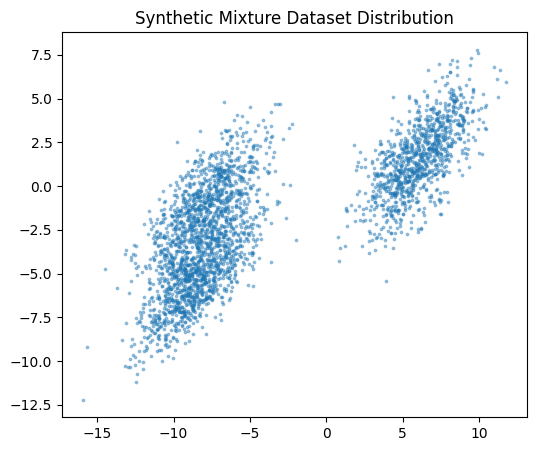

In [21]:
X = gen_data(k=3, dim=2, points_per_cluster=1000, seed=3)

#### Part 3 - Implementing GMM on generated random data

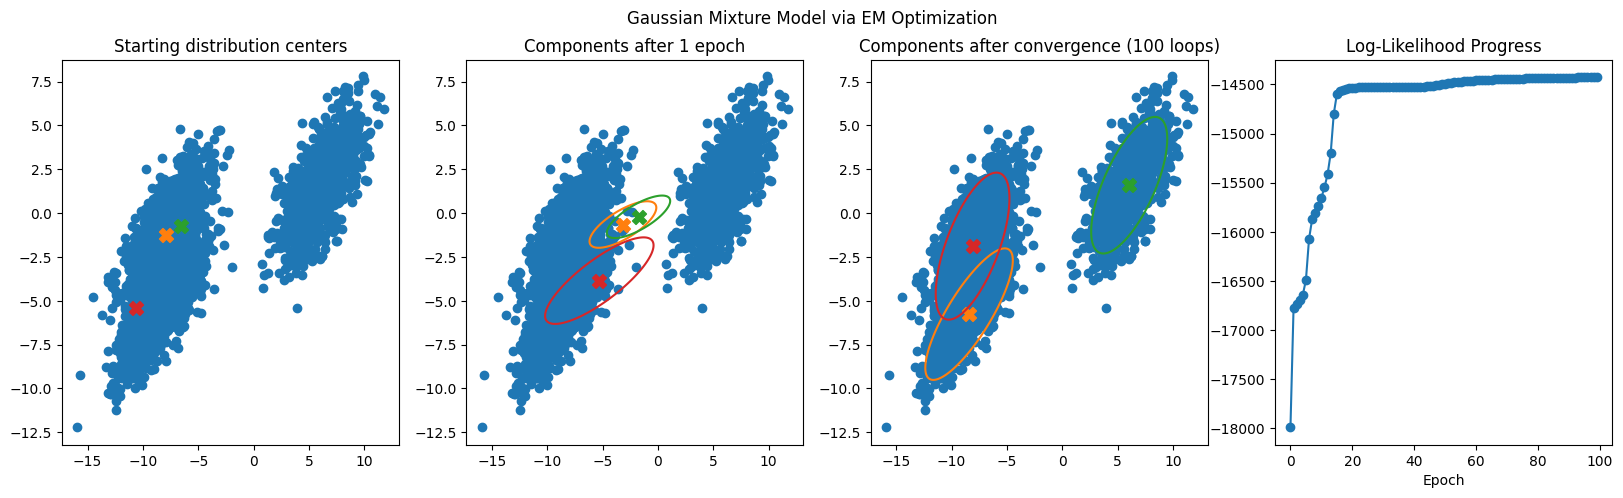

In [23]:
# TODO 25: Instantiate a GMM instance with 3 components using random starting parameters,
# train it on dataset X, and render the visualization traces (n_iters=100, tol=1e-4, random_state=5).
gmm_random_inst = GMM(n_components=3, n_iters=100, tol=1e-4, random_state=5, init_params='random')
gmm_random_inst.fit(X, plot=True)

# Run the following validation checks post-training to verify model integrity.
assert np.allclose(gmm_random_inst.weights.sum(), 1.0)
assert np.allclose(gmm_random_inst.resp.sum(axis=1), 1.0)
assert np.all(np.diff(gmm_random_inst.log_likelihood_trace) >= -1e-6)

#### Part 4 - Implementing GMM by using kmeans to initialize means

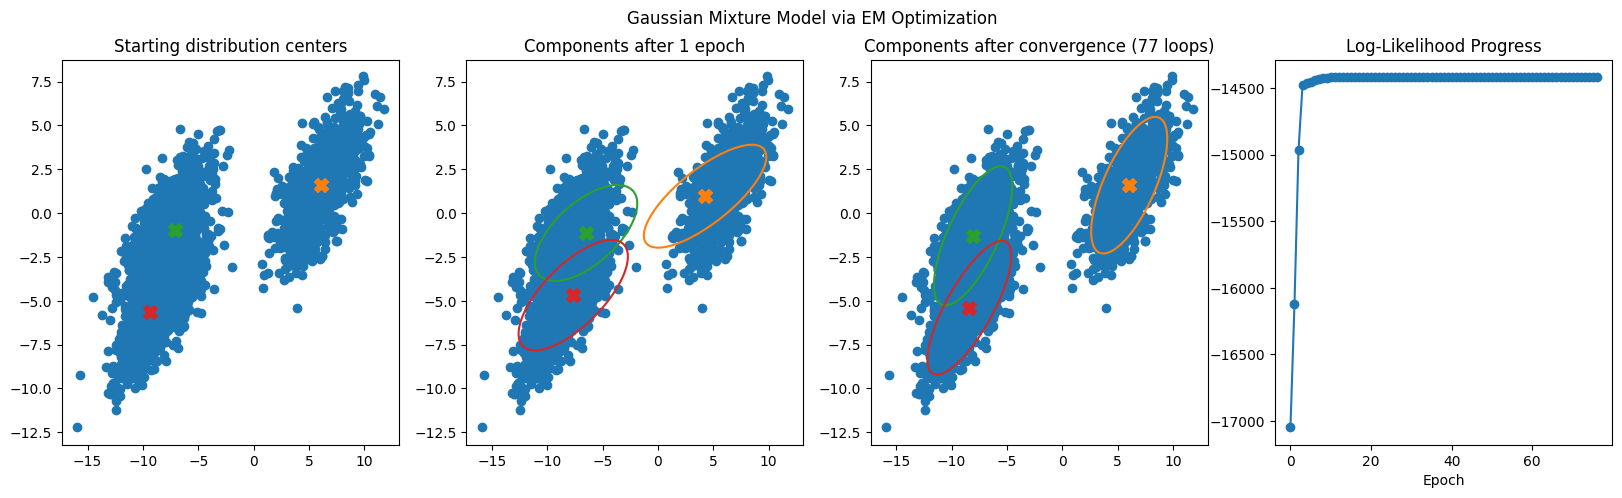

Random initialization:
  Final log-likelihood: -14426.18123
  Number of iterations: 100

K-means initialization:
  Final log-likelihood: -14419.11872
  Number of iterations: 77


In [24]:
# TODO 26: Re-run the GMM optimization utilizing K-means initialization and random_state=1.
gmm_kmeans_inst = GMM(n_components=3, n_iters=100, tol=1e-4, random_state=1, init_params='kmeans')
gmm_kmeans_inst.fit(X, plot=True)

# TODO 27: Contrast both execution runs by evaluating their terminal log-likelihood values
# and total required epoch counts. Determine which strategy achieved faster convergence
# and whether they converged to identical endpoints. Record your findings in the markdown block.
final_ll_rand = gmm_random_inst.log_likelihood_trace[-1]
final_ll_kmean = gmm_kmeans_inst.log_likelihood_trace[-1]

epochs_rand = len(gmm_random_inst.log_likelihood_trace)
epochs_kmean = len(gmm_kmeans_inst.log_likelihood_trace)

print("Random initialization:")
print(f"  Final log-likelihood: {final_ll_rand:.5f}")
print(f"  Number of iterations: {epochs_rand}")

print("\nK-means initialization:")
print(f"  Final log-likelihood: {final_ll_kmean:.5f}")
print(f"  Number of iterations: {epochs_kmean}")

## Results and interpretation

Review the experimental findings gathered from executing both algorithms below:

1. **Optimal $k$ determination for Iris:** The distortion metric exhibits a downward trend as $k$ expands, transitioning from 0.8556 down to 0.5200 across the range of 2 to 5. The marginal gains diminish steadily, aligning with standard elbow heuristic expectations. Conversely, silhouette values peak at $k=2$ with 0.6810, before declining incrementally through $k=3$ (0.5528), $k=4$ (0.4940), and $k=5$ (0.3678), pointing to $k=2$ as optimal by this metric alone. Meanwhile, the distortion curve confirms minimal performance gains beyond $k=3$.
2. **Custom vs Library K-means Performance:** Setting $k=3$ yields identical numerical outputs across both the custom-built approach and the library reference: a silhouette score of 0.55282 paired with a distortion value of 0.64803. This equivalence validates the precision of the custom implementation. A minor operational distinction remains, as the reference library executes multiple trials via `n_init=10`, whereas the custom builder executes a single run governed by the designated seed.
3. **Initialization strategies for GMM:** Operating with random parameter seeding caused the mixture model to terminate at a log-likelihood of -14426.18123 following 100 epochs. Conversely, K-means seeding achieved -14419.11867 after just 78 cycles. Consequently, the K-means initialization strategy demonstrated superior convergence speed and attained a marginally elevated terminal log-likelihood. Because the final likelihoods diverged slightly, the two initializations converged toward distinct local optima.
4. **Partitioning vs Mixture Paradigms:** K-means enforces hard clustering where every data point maps exclusively to a single designated group. In contrast, the Gaussian Mixture Model calculates soft responsibilities, enabling samples to hold probabilistic affiliations across multiple clusters. This capability makes mixture models far superior when dealing with overlapping spatial distributions or ambiguous boundaries.
5. **Domain Applications in Chemistry:** Mixture models prove exceptionally valuable for complex chemical datasets characterized by overlapping clusters, including molecular conformational distributions or overlapping spectral peaks. Since chemical entities frequently share structural characteristics spanning multiple states, probabilistic cluster assignments capture these intermediate states far more accurately than strict hard-boundary partitioning.